# プロジェクト概要
- 住宅データの線形回帰分析を行いました
- pandas、matplotlib、sklearnライブラリを使用しました

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### データの読み込み、および欠損値の確認など

In [25]:
#データの読み込み
all_sales = pd.read_csv('house.csv')
all_sales

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [26]:
#各コラムのデータタイプと欠損値を確認
print(all_sales.shape)
print(all_sales.columns)
print()
for col in all_sales.columns:
    print(col, "/", all_sales[col].dtype)
all_sales.isna().any()

(2930, 82)
Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr B

Order             False
PID               False
MS SubClass       False
MS Zoning         False
Lot Frontage       True
                  ...  
Mo Sold           False
Yr Sold           False
Sale Type         False
Sale Condition    False
SalePrice         False
Length: 82, dtype: bool

### 分析を通常の販売状態下のシングル家族に限定

In [27]:
#データフレームの抜きだし
sales = all_sales[all_sales["Bldg Type"]=="1Fam"]
sales = sales[sales["Sale Condition"]=="Normal"]
sales

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


### 分析データの可視化

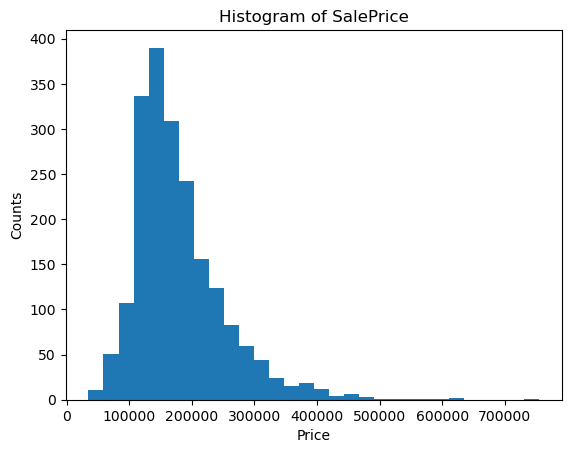

In [28]:
#ヒストグラムを作成
plt.hist(sales["SalePrice"],bins=30)
plt.title("Histogram of SalePrice")
plt.ylabel("Counts")
plt.xlabel("Price")
plt.show()

### 一部変数間の相関係数の導出

In [29]:
#corr()の実行
df = sales[["Overall Qual","Overall Cond","Year Built","Year Remod/Add","1st Flr SF","Garage Area","SalePrice"]]
df.corr()

,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,Garage Area,SalePrice
Overall Qual,1.000000,-0.090801,0.557903,0.511546,0.457955,0.550937,0.803270
Overall Cond,-0.090801,1.000000,-0.401541,0.095016,-0.153408,-0.178188,-0.113519
Year Built,0.557903,-0.401541,1.000000,0.534975,0.316339,0.487135,0.565165
Year Remod/Add,0.511546,0.095016,0.534975,1.000000,0.207490,0.342255,0.500908
1st Flr SF,0.457955,-0.153408,0.316339,0.207490,1.000000,0.464566,0.642466
Garage Area,0.550937,-0.178188,0.487135,0.342255,0.464566,1.000000,0.638594
SalePrice,0.803270,-0.113519,0.565165,0.500908,0.642466,0.638594,1.000000


### 単回帰分析の実行

In [30]:
model1 = LinearRegression()

X = sales[["Gr Liv Area"]]
y = sales["SalePrice"]
model1.fit(X,y)

print("coef:",model1.coef_)
print("intercept:",model1.intercept_)
print("R^2:",model1.score(X,y))

coef: [114.65347476]
intercept: 7855.6258500911645
R^2: 0.6009106618821846


### 単回帰分析結果の可視化

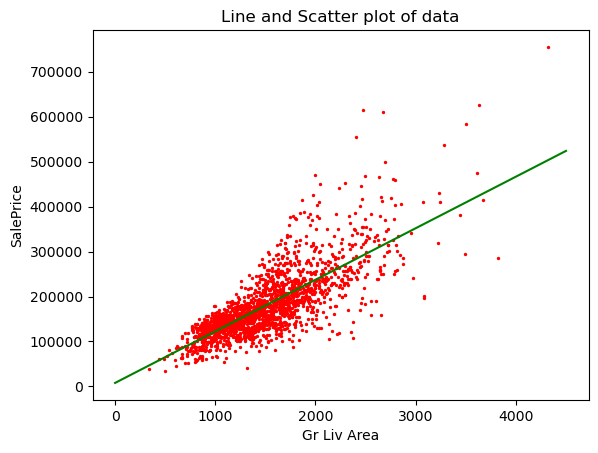

In [31]:
def plot_line(m,b,xmin,xmax):
    x_values = np.linspace(xmin,xmax,500)
    y_values = m*x_values + b
    plt.plot(x_values, y_values,'green',zorder=100)
    
x1 = sales["Gr Liv Area"]
y1 = sales["SalePrice"]
plt.scatter(x1,y1,s=2,color="red")
plot_line(model1.coef_, model1.intercept_,0,4500)
plt.title("Line and Scatter plot of data")
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.show()

### 重回帰分析の実行１

In [32]:
model2 = LinearRegression()

X = sales[["Gr Liv Area","Year Built"]]
y = sales["SalePrice"]
model2.fit(X,y)

print("coef:",model2.coef_)
print("intercept:",model2.intercept_)
print("R^2:",model2.score(X,y))

coef: [ 98.81721609 920.13298927]
intercept: -1778851.700982655
R^2: 0.7291598744854291


### 重回帰分析の実行２

In [33]:
model3 = LinearRegression()

X = sales[["Gr Liv Area", "Lot Area", "Garage Area", "Total Bsmt SF", "Open Porch SF", "Wood Deck SF", "Year Built"]]
y = sales["SalePrice"]
model3.fit(X,y)

print("coef:",model3.coef_)
print("intercept:",model3.intercept_)
print("R^2:",model3.score(X,y))

coef: [ 74.36181321   0.55871393  49.63762376  48.80446661  21.99490272
  32.59822183 534.02553827]
intercept: -1066504.8343010272
R^2: 0.81905979431861
